1. Input Data

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)


In [2]:
import numpy as np
import torch

# Input data
data = np.load("frozen_soil_sensor_dataset_train_80.npz")

all_T        = data["all_T"]         # (n_case, Nt, Nz)   
all_T_sensor = data["all_T_sensor"]  # (n_case, Nt, n_s)  
params_arr   = data["params_arr"]    # (n_case, n_param)  SFCC parameter
curve_ids    = data["curve_ids"]     # (n_case,)
t            = data["t"]             # (Nt,)
z            = data["z"]             # (Nz,)
sensor_z     = data["sensor_z"]      # (n_s,)
sensor_idx   = data["sensor_idx"]    # (n_s,)

print("all_T       :", all_T.shape)
print("all_T_sensor:", all_T_sensor.shape)
print("params_arr  :", params_arr.shape)
print("curve_ids   :", curve_ids.shape)
print("t           :", t.shape)
print("z           :", z.shape)
print("sensor_z    :", sensor_z)
print("sensor_idx  :", sensor_idx)

all_T       : (80, 61, 49)
all_T_sensor: (80, 61, 11)
params_arr  : (80, 6)
curve_ids   : (80,)
t           : (61,)
z           : (49,)
sensor_z    : [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
sensor_idx  : [ 4  8 12 16 20 24 28 32 36 40 44]


2. Inverse DeepONet Development

2.1. reshape

In [3]:
X_sensor_np = all_T_sensor
X_sensor = torch.from_numpy(X_sensor_np).permute(0, 2, 1).float()
params   = torch.from_numpy(params_arr).float()

print("X_sensor for CNN:", X_sensor.shape)
print("params          :", params.shape)


X_sensor for CNN: torch.Size([80, 11, 61])
params          : torch.Size([80, 6])


2.2. NN architecture

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):
    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
    
        self.pool = nn.AdaptiveAvgPool1d(1)  # Average Temp
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class TrunkNet(nn.Module):
    def __init__(self, latent_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):          
        if T_query.dim() == 1:
            x = T_query.unsqueeze(-1)    # (n_T, 1)
        else: 
            x = T_query.unsqueeze(-1)
        t = self.net(x)                  # (..., latent_dim)
        return t


class InverseDeepONetMonotone(nn.Module):
    def __init__(self,
                 n_sensors: int,
                 latent_dim: int = 8,
                 theta_sat: float = 0.5):
        super().__init__()
        self.branch     = BranchCNN(n_sensors, latent_dim)
        self.trunk      = TrunkNet(latent_dim)
        self.theta_sat  = theta_sat
        self.latent_dim = latent_dim  
        self.fc_res = nn.Linear(latent_dim, 1)   
        self.fc_scale = nn.Linear(latent_dim, 1)

    def forward(self, X_sensor, T_query):
   
        device = X_sensor.device
        T_query = T_query.to(device)

        B   = X_sensor.size(0)
        n_T = T_query.numel()

        mask_neg = (T_query < 0)          # (n_T,)
        mask_pos = ~mask_neg              # (n_T,)

        idx_neg = torch.nonzero(mask_neg, as_tuple=False).squeeze(-1)  # (n_T_neg,)
        idx_pos = torch.nonzero(mask_pos, as_tuple=False).squeeze(-1)  # (n_T_pos,)

        T_neg = T_query[idx_neg]          # (n_T_neg,)

        # b: (B, latent_dim)
        b = self.branch(X_sensor)         # (B, latent_dim)

        theta_res_frac = torch.sigmoid(self.fc_res(b))   # (B, 1), 0~1
        theta_res = theta_res_frac * self.theta_sat      # (B, 1)

        t_neg = self.trunk(T_neg)         # (n_T_neg, latent_dim)

        # raw: (B, n_T_neg)
        theta_raw_neg = torch.matmul(b, t_neg.T)   # (B, n_T_neg)

        scale = 0.2 + 5.0 * torch.sigmoid(self.fc_scale(b))   # (B,1) > 0
        delta = F.softplus(theta_raw_neg) * scale              # (B,n_T_neg)
        theta_cum = torch.cumsum(delta, dim=1)     # (B, n_T_neg)

        eps = 1e-6
        s_neg = theta_cum / (theta_cum[:, -1:].clone() + eps)   # (B, n_T_neg), 0~1
        theta_neg = theta_res + (self.theta_sat - theta_res) * s_neg  # (B, n_T_neg)
        theta = torch.zeros(B, n_T, device=device)

        if idx_neg.numel() > 0:
            theta[:, idx_neg] = theta_neg

        if idx_pos.numel() > 0:
            theta[:, idx_pos] = self.theta_sat

        return theta

3. Connect PDE solver

3.1. K and C_eff functions

In [5]:
import torch.nn as nn
import torch.nn.functional as F

# ===== Constitutive Parameters =====
n_porosity    = 0.5         # Porosity
theta_s_fixed = 1.0 - n_porosity  

K_s = 8.80*86400       # W/m/K   
K_w = 0.56*86400       # W/m/K   
K_i = 2.26*86400       # W/m/K   

C_s = 2.13*1e6         # J/m3/K  
C_w = 4.19e6           # J/m3/K  
C_i = 2.13e6           # J/m3/K  

L     = 3.34e5         # J/kg    
rho_w = 1000.0         # kg/m3    


In [ ]:
def interp_1d(T_nodes: torch.Tensor,
              T_query: torch.Tensor,
              y_query: torch.Tensor) -> torch.Tensor:
    T_min, T_max = T_query[0], T_query[-1]
    T_clamp = torch.clamp(T_nodes, T_min, T_max)

    n_T = T_query.shape[0]
    pos = (T_clamp - T_min) / (T_max - T_min) * (n_T - 1)

    idx0 = torch.floor(pos).long()
    idx1 = torch.clamp(idx0 + 1, max=n_T - 1)
    w    = (pos - idx0.float()).clamp(0.0, 1.0)

    y0 = y_query[idx0]
    y1 = y_query[idx1]
    y  = (1.0 - w) * y0 + w * y1
    return y


def sfcc_and_deriv_finite_diff_batch(
    deeponet: nn.Module,
    X_sensor_batch: torch.Tensor,  # (B, n_sensors, Nt)
    T_query: torch.Tensor,         # (n_T,)
    eps_T: float = 0.2,
    dtheta_max: float = 5.0
):
    device = T_query.device
    X_sensor_batch = X_sensor_batch.to(device)
    T_query = T_query.to(device)

    eps = float(eps_T)
    T_min, T_max = T_query[0], T_query[-1]
    T_plus  = torch.clamp(T_query + eps,  T_min, T_max)
    T_minus = torch.clamp(T_query - eps,  T_min, T_max)

    theta_center = deeponet(X_sensor_batch, T_query)   # (B, n_T)
    theta_plus   = deeponet(X_sensor_batch, T_plus)    # (B, n_T)
    theta_minus  = deeponet(X_sensor_batch, T_minus)   # (B, n_T)

    dtheta = (theta_plus - theta_minus) / (2.0 * eps)  # (B, n_T)
    dtheta = torch.clamp(dtheta, 0.0, dtheta_max)

    return theta_center, dtheta


In [ ]:
def compute_K_from_theta(theta_w: torch.Tensor) -> torch.Tensor:
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed

    Ks_part = K_s ** theta_s
    Kw_part = K_w ** theta_w
    Ki_part = K_i ** theta_i

    return Ks_part * Kw_part * Ki_part


def compute_Ceff_from_theta_fdiff(
    theta_w: torch.Tensor,      # (Nz,)
    T_nodes: torch.Tensor,      # (Nz,)
    T_query: torch.Tensor,      # (n_T,)
    dtheta_query: torch.Tensor  # (n_T,)
) -> torch.Tensor:
   
    theta_i = torch.clamp(n_porosity - theta_w, 0.0, n_porosity)
    theta_s = theta_s_fixed
  
    C_T = theta_s * C_s + theta_w * C_w + theta_i * C_i   # (Nz,)
 
    dtheta_nodes = interp_1d(T_nodes, T_query, dtheta_query)  # (Nz,)

    C_eff = C_T + L * rho_w * dtheta_nodes
    return C_eff

3.2 PDE solver

In [ ]:
def solve_one_case_with_sfcc_fdiff(
    theta_query: torch.Tensor,   # (n_T,)
    dtheta_query: torch.Tensor,  # (n_T,)
    T_query: torch.Tensor,       # (n_T,)
    z: torch.Tensor,             # (Nz,)
    t: torch.Tensor,             # (Nt,)
    T_initial: float,
    T_top_func
) -> torch.Tensor:
    
    device = theta_query.device
    z = z.to(device)
    t = t.to(device)

    dz  = z[1] - z[0]
    dt  = t[1] - t[0]
    Nz  = z.numel()
    Nt  = t.numel()
    dz2 = dz * dz

    T0 = torch.full((Nz,), float(T_initial),
                    dtype=torch.float32, device=device)
    T_list = [T0]  

    for n in range(Nt - 1):
        Tn = T_list[-1]   

        time_n1     = float(t[n+1].item())
        T_top_n1    = float(T_top_func(time_n1))

        theta_w = interp_1d(Tn, T_query, theta_query)   # (Nz,)
        K_T     = compute_K_from_theta(theta_w)         # (Nz,)
        C_eff   = compute_Ceff_from_theta_fdiff(
            theta_w, Tn, T_query, dtheta_query
        )                                               # (Nz,)

        K_half = 0.5 * (K_T[1:] + K_T[:-1])            # (Nz-1,)

        M = Nz - 2  

        a = torch.zeros(M-1, device=device)
        b = torch.zeros(M,   device=device)
        c = torch.zeros(M-1, device=device)
        d_vec = torch.zeros(M, device=device)

        for j in range(1, Nz-1):
            m = j - 1

            K_left  = K_half[j-1]     # K_{j-1/2}
            K_right = K_half[j]       # K_{j+1/2}
            Ci      = C_eff[j]

            a_m = -K_left  / dz2
            c_m = -K_right / dz2
            b_m = Ci / dt + (K_left + K_right) / dz2
            d_m = Ci / dt * Tn[j]

            if j == 1:
                b_m = b_m + a_m

            if j == Nz-2:
                d_m -= c_m * T_top_n1

            b[m]     = b_m
            d_vec[m] = d_m
            if m > 0:
                a[m-1] = a_m
            if m < M-1:
                c[m] = c_m

        A = torch.diag(b) + torch.diag(a, diagonal=-1) + torch.diag(c, diagonal=1)
        T_internal = torch.linalg.solve(A, d_vec)   # (M,)

        T_next = torch.empty_like(Tn)
        T_next[1:-1] = T_internal
        T_next[0]    = T_next[1]   # zero-flux
        T_next[-1]   = T_top_n1

        T_list.append(T_next)

    T_field = torch.stack(T_list, dim=0)   # (Nt, Nz)
    return T_field


3.3 Connect DeepONet and PDE

In [ ]:
class FrozenSoilDM(nn.Module):
    def __init__(self,
                 deeponet: nn.Module,
                 z_grid,
                 t_grid,
                 sensor_idx,
                 T_top_func,
                 T_initial: float,
                 theta_sat: float = 0.5,
                 T_min: float = -15.0,
                 T_max: float = 0.0,
                 n_T_query: int = 100):
        super().__init__()

        self.deeponet       = deeponet
        self.T_initial      = T_initial
        self.T_top_func     = T_top_func
        self.theta_sat      = theta_sat

        z_grid = np.asarray(z_grid, dtype=np.float32)
        t_grid = np.asarray(t_grid, dtype=np.float32)
        self.register_buffer("z", torch.from_numpy(z_grid))
        self.register_buffer("t", torch.from_numpy(t_grid))
        self.register_buffer(
            "sensor_idx",
            torch.as_tensor(sensor_idx, dtype=torch.long)
        )

        T_query_np = np.linspace(T_min, T_max, n_T_query).astype("float32")
        self.register_buffer("T_query", torch.from_numpy(T_query_np))

    def forward(self, X_sensor: torch.Tensor):
        
        device = X_sensor.device
        B, n_sensors, Nt_obs = X_sensor.shape

        z       = self.z.to(device)
        t       = self.t.to(device)
        T_query = self.T_query.to(device)
        idx_s   = self.sensor_idx.to(device)

        Nz = z.numel()
        Nt = t.numel()
        assert Nt_obs == Nt, "The number of observed time steps must be consistent with Nt in t_grid"

        theta_batch, dtheta_batch = sfcc_and_deriv_finite_diff_batch(
            self.deeponet,
            X_sensor,    # (B, n_sensors, Nt)
            T_query,     # (n_T,)
            eps_T=0.2,
            dtheta_max=5.0
        )  # (B, n_T), (B, n_T)

        T_fields = []
        for b in range(B):
            T_field = solve_one_case_with_sfcc_fdiff(
               theta_query=theta_batch[b],
               dtheta_query=dtheta_batch[b],
               T_query=T_query,
               z=z, t=t,
               T_initial=self.T_initial,
               T_top_func=self.T_top_func
            )
            T_fields.append(T_field)

        T_all = torch.stack(T_fields, dim=0)     # (B, Nt, Nz)
        T_sensor = T_all[:, :, idx_s]   # (B, Nt, n_sensors)

        return T_all, T_sensor


4. Loss function + training

4.1. Loss function

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

n_case, n_sensors, Nt = X_sensor.shape
Nz = len(z)

latent_dim = 8      

def T_top(time_day: float) -> float:
    if time_day <= 0.5:
        return -5.0
    elif time_day <= 5.0:
        return 0.0

T_initial = -15.0  

deeponet = InverseDeepONetMonotone(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=0.5,
).to(device)

dm_model = FrozenSoilDM(
    deeponet=deeponet,
    z_grid=z,
    t_grid=t,
    sensor_idx=sensor_idx,
    T_top_func=T_top,
    T_initial=float(T_initial),
    theta_sat=0.5,
    T_min=-15.0,
    T_max=0.0,
    n_T_query=50,   
).to(device)

Y_sensor_np = all_T_sensor          # (n_case, Nt, n_sensors)
Y_sensor    = torch.from_numpy(Y_sensor_np).float()  

# ----------------------------------------------------------------------------------------------------------
dataset = TensorDataset(X_sensor, Y_sensor)
batch_size = 10                      
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

optimizer = torch.optim.Adam(dm_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()            

dt = float(t[1] - t[0])

sensor_z_t = torch.from_numpy(sensor_z).float().to(device)  # (n_sensors,)
z_im1 = sensor_z_t[:-2]   # z_{i-1}
z_i   = sensor_z_t[1:-1]  # z_i
z_ip1 = sensor_z_t[2:]    # z_{i+1}
h1 = (z_i - z_im1).view(1, 1, -1)   # (1,1,n_s-2)
h2 = (z_ip1 - z_i).view(1, 1, -1)   # (1,1,n_s-2)
# three-point second derivative coefficients for nonuniform spacing:
# f''(z_i) ≈ 2*( f_{i-1}/(h1*(h1+h2)) - f_i/(h1*h2) + f_{i+1}/(h2*(h1+h2)) )
coef_im1 = 2.0 / (h1 * (h1 + h2))
coef_i   = -2.0 / (h1 * h2)
coef_ip1 = 2.0 / (h2 * (h1 + h2))

lam_t  = 0.5   # dT/dt loss weight
lam_z2 = 0.1*0.1*0.5*0.5   # d2T/dz2 loss weight

n_epochs = 200
early_stop_T = 0.02  

loss_hist      = []
loss_T_hist    = []
loss_dTdt_hist = []
loss_d2z_hist  = []

for epoch in range(1, n_epochs + 1):
    dm_model.train()
    running_loss = 0.0
    running_T    = 0.0
    running_dTdt = 0.0
    running_d2z  = 0.0
    n_seen       = 0

    for X_batch, Y_batch in train_loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        optimizer.zero_grad()

        _, T_sensor_pred = dm_model(X_batch)

        loss_T = criterion(T_sensor_pred, Y_batch)

        dTdt_pred = (T_sensor_pred[:, 1:, :] - T_sensor_pred[:, :-1, :]) / dt  # (B, Nt-1, n_s)
        dTdt_obs  = (Y_batch[:, 1:, :]       - Y_batch[:, :-1, :])       / dt
        loss_dTdt = criterion(dTdt_pred, dTdt_obs)

        Tm1_pred = T_sensor_pred[:, :, :-2]   # (B, Nt, n_s-2)
        Ti_pred  = T_sensor_pred[:, :, 1:-1]  # (B, Nt, n_s-2)
        Tp1_pred = T_sensor_pred[:, :, 2:]    # (B, Nt, n_s-2)
        d2Tdz2_pred = coef_im1 * Tm1_pred + coef_i * Ti_pred + coef_ip1 * Tp1_pred

        Tm1_obs = Y_batch[:, :, :-2]
        Ti_obs  = Y_batch[:, :, 1:-1]
        Tp1_obs = Y_batch[:, :, 2:]
        d2Tdz2_obs = coef_im1 * Tm1_obs + coef_i * Ti_obs + coef_ip1 * Tp1_obs

        loss_d2Tdz2 = criterion(d2Tdz2_pred, d2Tdz2_obs)

        loss_t  = lam_t  * loss_dTdt
        loss_z2 = lam_z2 * loss_d2Tdz2
        loss = loss_T + loss_t + loss_z2 

        loss.backward()
        torch.nn.utils.clip_grad_norm_(dm_model.parameters(), max_norm=1.0)
        optimizer.step()

        bs = X_batch.size(0)
        n_seen += bs
        running_T    += loss_T.item()        * bs
        running_dTdt += loss_t.item()        * bs  
        running_d2z  += loss_z2.item()       * bs
        running_loss += loss.item()          * bs

    epoch_loss  = running_loss / n_seen
    epoch_T     = running_T    / n_seen
    epoch_dTdt  = running_dTdt / n_seen
    epoch_d2z   = running_d2z  / n_seen

    loss_hist.append(epoch_loss)
    loss_T_hist.append(epoch_T)
    loss_dTdt_hist.append(epoch_dTdt)
    loss_d2z_hist.append(epoch_d2z)

    print(
        f"Epoch {epoch:03d} | "
        f"total={epoch_loss:.3e} | "
        f"T={epoch_T:.3e} | "
        f"lam_t*dTdt={epoch_dTdt:.3e} | "     
        f"lam_z2*d2Tdz2={epoch_d2z:.3e}"   
    )

    if epoch_T < early_stop_T:
        print(f"Early stop at epoch {epoch:03d} (T loss {epoch_T:.3e} < {early_stop_T})")
        break

Using device: cuda


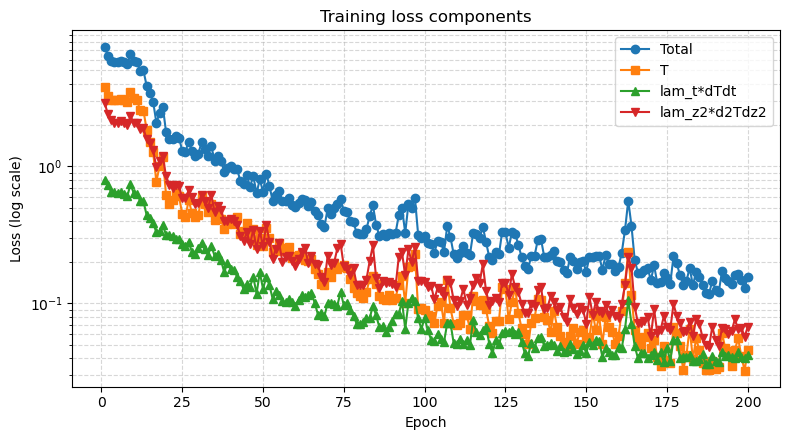

Saved: loss_components.xlsx


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

epochs = np.arange(1, len(loss_hist) + 1)

plt.figure(figsize=(8, 4.5))
plt.plot(epochs, loss_hist,      marker="o", label="Total")
plt.plot(epochs, loss_T_hist,    marker="s", label="T")
plt.plot(epochs, loss_dTdt_hist, marker="^", label="lam_t*dTdt")
plt.plot(epochs, loss_d2z_hist,  marker="v", label="lam_z2*d2Tdz2")

plt.yscale("log")  
plt.xlabel("Epoch")
plt.ylabel("Loss (log scale)")
plt.title("Training loss components")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

df = pd.DataFrame({
    "epoch": epochs,
    "loss_total": np.array(loss_hist, dtype=float),
    "loss_T": np.array(loss_T_hist, dtype=float),
    "loss_lam_t_dTdt": np.array(loss_dTdt_hist, dtype=float),
    "loss_lam_z2_d2Tdz2": np.array(loss_d2z_hist, dtype=float),
})

out_xlsx = "loss_components_80.xlsx"
df.to_excel(out_xlsx, index=False)
print(f"Saved: {out_xlsx}")

4.2. Saving the parameters of DeepONet

In [ ]:
# Save DeepONet parameter
torch.save(dm_model.deeponet.state_dict(), "deeponet_sfcc_operator_train_80.pt")
print("Saved: deeponet_sfcc_operator_train_80.pt")


# Save Temp field
dm_model.eval()

with torch.no_grad():
    T_all_pred, T_sensor_pred = dm_model(X_sensor.to(device))

np.save("T_all_pred_train_80.npy", T_all_pred.cpu().numpy())
np.save("T_sensor_pred_train_80.npy", T_sensor_pred.cpu().numpy())

print("Saved: T_all_pred.npy, T_sensor_pred.npy")


Saved: deeponet_sfcc_operator_train_80.pt
Saved: T_all_pred.npy, T_sensor_pred.npy
